# Trabajo Práctico N.° 2 — Análisis de Series Temporales

## 10 — Darts: librería multi-modelo

**Objetivo de este notebook:** cubrir la categoría "Darts" del punto 2 de la consigna del TP2, probando varios modelos dentro de una misma librería unificada (`TimeSeries` como estructura de datos común) y quedándose con el mejor por serie.

**Alcance:** se usan **`ExponentialSmoothing`, `AutoARIMA`, `Theta` y `FFT`** — los cuatro corren en CPU sin PyTorch. Se descarta deliberadamente `RNNModel` (LSTM vía Darts): esa combinación de librerías exige `pytorch_lightning>=2.0`, que es incompatible con NeuralProphet (`<2.0`) en el mismo entorno (ver `feedback_dl_libs_compat` en la memoria del proyecto). No es una pérdida real: la red LSTM ya se cubrió con TensorFlow/Keras en `08_lstm.ipynb`, así que repetirla con otro backend sería redundante.

**Dataset:** se usa `serie_california_tratada.csv` (salida de `07b_tratamiento_datos.ipynb`, ya sin huecos en el índice) — por eso ya no hace falta el reindex+interpolate manual que llevaba antes esta sección.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from darts import TimeSeries
from darts.models import ExponentialSmoothing, AutoARIMA, Theta, FFT
from sklearn.metrics import mean_absolute_error, mean_squared_error

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

datos = pd.read_csv(
    PROJECT_ROOT / "data/processed/serie_california_tratada.csv",
    index_col="datetime_utc",
    parse_dates=True,
)
datos.index = datos.index.tz_localize(None)

HORAS_TEST = 24 * 7
VENTANA_DIAS = 365
MODELOS = {
    "ExponentialSmoothing": lambda: ExponentialSmoothing(),
    "AutoARIMA": lambda: AutoARIMA(),
    "Theta": lambda: Theta(),
    "FFT": lambda: FFT(),
}
print(f"Modelos a comparar: {list(MODELOS.keys())}")

Modelos a comparar: ['ExponentialSmoothing', 'AutoARIMA', 'Theta', 'FFT']


## 1. Ajuste y comparación por serie

Mismo criterio que en los notebooks anteriores: ventana de 1 año, holdout de 168 horas. `TimeSeries.from_series(..., freq="h")` exige un índice regular — con `serie_california_tratada.csv` ya no hay huecos que reindexar/interpolar acá (antes esto rompía `ExponentialSmoothing`/`Theta` con `NaN` y degradaba silenciosamente `AutoARIMA`/`FFT`; el fix quedó centralizado en `07b_tratamiento_datos.ipynb`).

In [2]:
resultados_darts = {}

for col in datos.columns:
    print(f"\n{'='*60}\n{col}\n{'='*60}")
    serie = datos[col].iloc[-(VENTANA_DIAS * 24):]

    ts = TimeSeries.from_series(serie, freq="h")
    train, test = ts[:-HORAS_TEST], ts[-HORAS_TEST:]

    resultados_darts[col] = {}
    for nombre, constructor in MODELOS.items():
        try:
            modelo = constructor()
            modelo.fit(train)
            pronostico = modelo.predict(HORAS_TEST)
            real = test.values().flatten()
            pred = pronostico.values().flatten()
            mae = mean_absolute_error(real, pred)
            rmse = mean_squared_error(real, pred) ** 0.5
            resultados_darts[col][nombre] = {"MAE": mae, "RMSE": rmse, "_pred": pred.tolist()}
            print(f"  [{nombre}] MAE={mae:.5f}  RMSE={rmse:.5f}")
        except Exception as exc:
            print(f"  [{nombre}] FALLÓ: {exc}")

    resultados_darts[col]["_test_real"] = test.values().flatten().tolist()


ozono_ppm


  [ExponentialSmoothing] MAE=0.01732  RMSE=0.02092


  [AutoARIMA] MAE=0.01643  RMSE=0.02060
  [Theta] FALLÓ: Multiplicative seasonality is not appropriate for zero and negative values
  [FFT] MAE=0.00937  RMSE=0.01140

temperatura_c


  [ExponentialSmoothing] MAE=1.19458  RMSE=1.53111


  [AutoARIMA] MAE=1.75266  RMSE=2.25291
  [Theta] MAE=1.27519  RMSE=1.57190
  [FFT] MAE=3.00874  RMSE=3.31536

radiacion_ghi_wm2


  [ExponentialSmoothing] MAE=45.18090  RMSE=65.21970


  [AutoARIMA] MAE=285.15718  RMSE=315.43601
  [Theta] FALLÓ: Multiplicative seasonality is not appropriate for zero and negative values
  [FFT] MAE=68.15817  RMSE=94.44277


## 2. Mejor modelo Darts por serie, graficado

ozono_ppm: mejor modelo Darts = FFT  (MAE=0.00937)
temperatura_c: mejor modelo Darts = ExponentialSmoothing  (MAE=1.19458)
radiacion_ghi_wm2: mejor modelo Darts = ExponentialSmoothing  (MAE=45.18090)


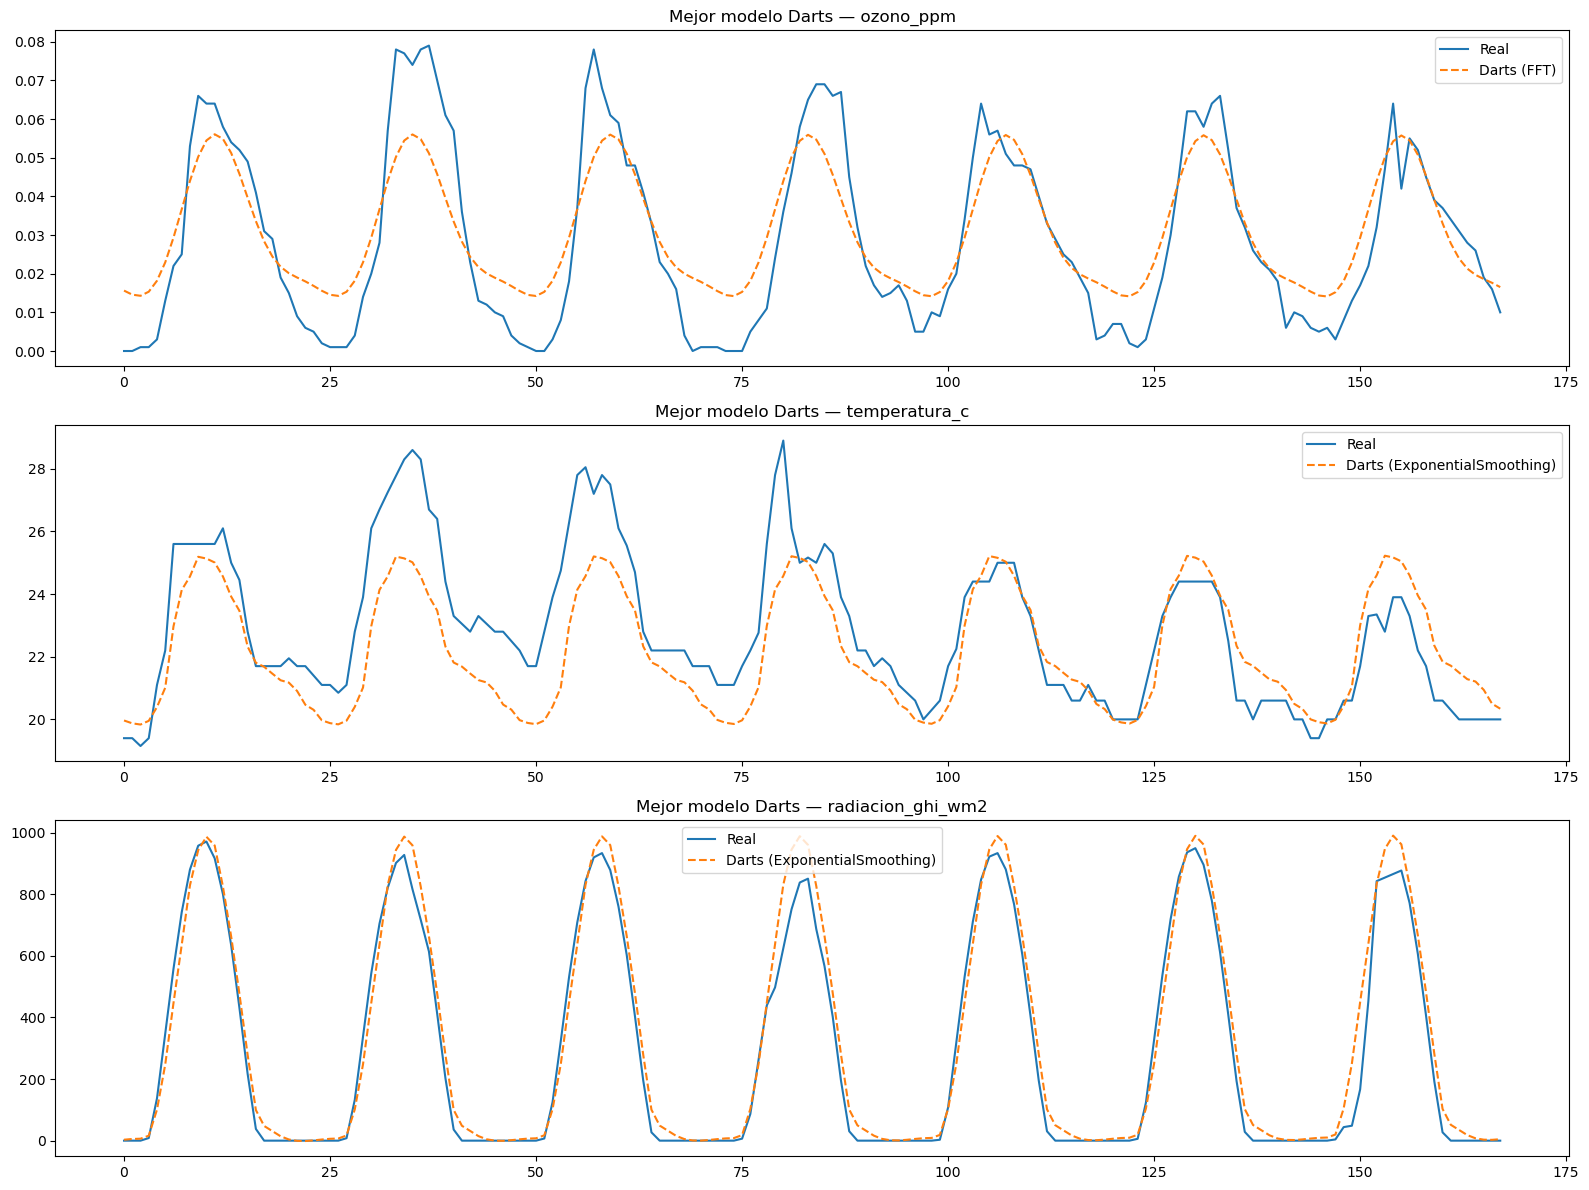

In [3]:
mejores_darts = {}
fig, axes = plt.subplots(len(datos.columns), 1, figsize=(16, 12))

for ax, col in zip(axes, datos.columns):
    candidatos = {k: v for k, v in resultados_darts[col].items() if not k.startswith("_")}
    mejor = min(candidatos, key=lambda m: candidatos[m]["MAE"])
    mejores_darts[col] = mejor
    print(f"{col}: mejor modelo Darts = {mejor}  (MAE={candidatos[mejor]['MAE']:.5f})")

    ax.plot(resultados_darts[col]["_test_real"], label="Real")
    ax.plot(resultados_darts[col][mejor]["_pred"], label=f"Darts ({mejor})", linestyle="--")
    ax.set_title(f"Mejor modelo Darts — {col}")
    ax.legend()

plt.tight_layout()
plt.show()

## 3. Guardado de resultados

In [4]:
resultados_a_guardar = {
    col: {
        "mejor_modelo": mejores_darts[col],
        **{k: {"MAE": v["MAE"], "RMSE": v["RMSE"]} for k, v in resultados_darts[col].items() if not k.startswith("_")},
    }
    for col in datos.columns
}

destino = PROJECT_ROOT / "data/processed/resultados_darts.json"
destino.write_text(json.dumps(resultados_a_guardar, indent=2), encoding="utf-8")

print(json.dumps(resultados_a_guardar, indent=2))
print(f"\nGuardado en {destino}")
print("\nProyecto listo para continuar con 11_automl.ipynb")

{
  "ozono_ppm": {
    "mejor_modelo": "FFT",
    "ExponentialSmoothing": {
      "MAE": 0.01732147376088952,
      "RMSE": 0.02092373220841844
    },
    "AutoARIMA": {
      "MAE": 0.016430367528582658,
      "RMSE": 0.020600238151088416
    },
    "FFT": {
      "MAE": 0.009370515806684073,
      "RMSE": 0.011399096807258126
    }
  },
  "temperatura_c": {
    "mejor_modelo": "ExponentialSmoothing",
    "ExponentialSmoothing": {
      "MAE": 1.194577553729275,
      "RMSE": 1.531110323875826
    },
    "AutoARIMA": {
      "MAE": 1.7526561157580114,
      "RMSE": 2.2529082571092442
    },
    "Theta": {
      "MAE": 1.2751884680672796,
      "RMSE": 1.5718965815266759
    },
    "FFT": {
      "MAE": 3.0087428874408175,
      "RMSE": 3.3153559707385276
    }
  },
  "radiacion_ghi_wm2": {
    "mejor_modelo": "ExponentialSmoothing",
    "ExponentialSmoothing": {
      "MAE": 45.180903961333854,
      "RMSE": 65.21970496213073
    },
    "AutoARIMA": {
      "MAE": 285.1571773696127,
 